# Qwen3.5-122B-A10B 对话模型
Gated DeltaNet + Mixture-of-Experts · 通义千问系列


---
## 一、项目简介

### 1.1 官方介绍

**Qwen3.5-122B-A10B** 是阿里通义千问系列的最新 MoE（Mixture-of-Experts）大语言模型，采用创新的 Gated DeltaNet + Gated Attention 混合架构。总参数量 122B，每次推理仅激活 10B 参数，兼顾高性能与高效率。

主要特性：
- MoE 架构：122B 总参 / 10B 激活，推理速度快于同规模稠密模型
- 混合架构：Gated DeltaNet（高效长序列）+ Gated Attention（精准注意力）
- 原生 BF16 训练，无需 FP8 反量化
- Apache 2.0 开源许可证

### 1.2 本项目

| 项目 | 内容 |
|------|------|
| 实现类型 | 推理 + WebUI（Gradio 对话界面） |
| 模型 | [Qwen/Qwen3.5-122B-A10B](https://huggingface.co/Qwen/Qwen3.5-122B-A10B) |
| 推理引擎 | Transformers 5.9.0 + PyTorch 2.5.1 |
| 许可证 | Apache 2.0 |
| 推理速度 | ~7 tok/s（4×80GB 配置） |
| 模型加载时间 | ~51 分钟（831 个权重分片） |

### 1.3 界面截图

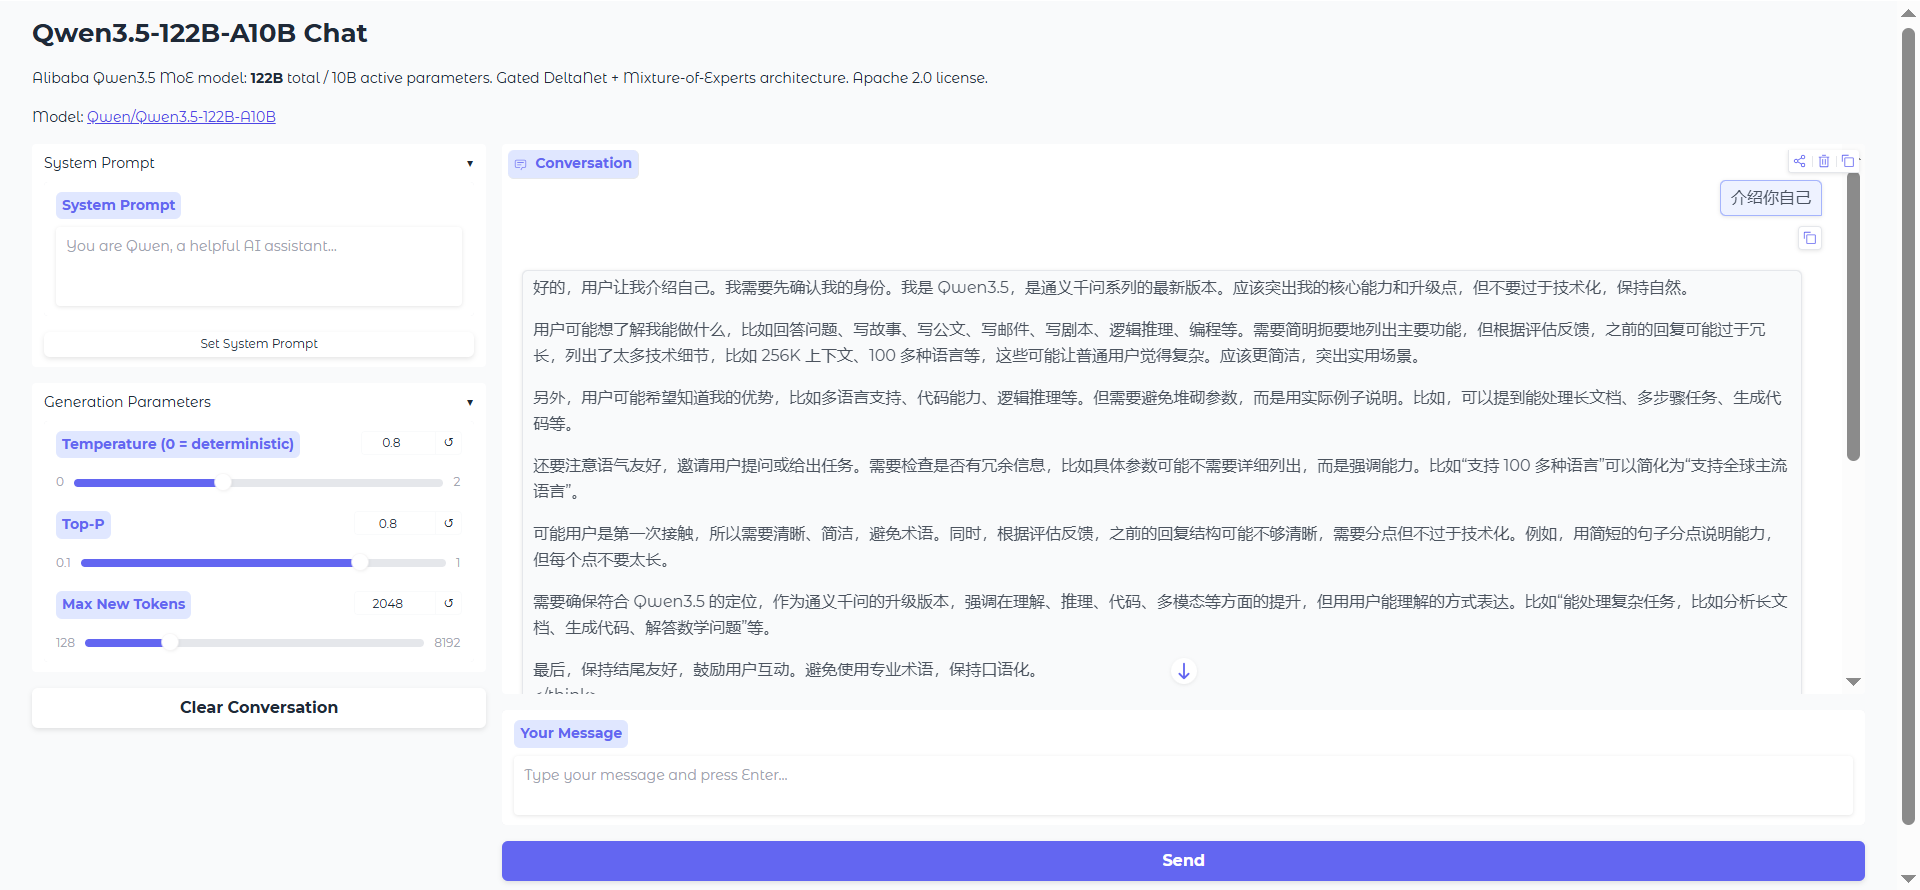


---
## 二、官方链接

| 类型 | 链接 |
|------|------|
| HuggingFace 仓库 | [Qwen/Qwen3.5-122B-A10B](https://huggingface.co/Qwen/Qwen3.5-122B-A10B) |
| GitHub 仓库 | [QwenLM/Qwen3.5](https://github.com/QwenLM/Qwen3.5) |
| 技术博客 | [Qwen3.5 技术报告](https://qwenlm.github.io/blog/qwen3.5/) |


---
## 三、算力推荐

| 配置 | 实例规格 | 显存 | 推理速度 | 说明 |
|------|----------|:----:|:--------:|------|
| 推荐配置 | P1.4xlarge | 4 × 80GB | ~7 tok/s | 模型 ~234GB（BF16），4 卡均匀分布 |

> ⚠️ 122B 模型权重约 234GB（BF16），多卡分布式推理是目前唯一可行方案。


---
## 四、推理服务配置

以下为部署推理服务时的必填参数：

| 参数 | 值 |
|------|------|
| 镜像 | 自构建镜像（基于 CUDA 12.x / CuDNN 9 / Ubuntu 22.04） |
| 模型 | Qwen3.5-122B-A10B（挂载到 `/gemini/pretrain`） |
| 代码 | `app.py` + `start.sh`（上传到代码目录） |
| 启动命令 | `bash /gemini/code/start.sh` |
| 端口 | 7860 |
| 路由模式 | HTTP |
| 实例规格 | P1.4xlarge（4×80GB） |

> 注意：推理服务模型加载约需 1 小时（831 权重分片），请耐心等待。


---
## 五、使用说明

### 5.1 一键启动

推理服务启动命令：

```bash
bash /gemini/code/start.sh
```

### 5.2 访问方式

1. 推理服务启动后，等待模型加载完成（约 50-60 分钟）
2. 日志中出现 `[START] Model ready` 表示加载完毕
3. 打开推理服务的**公网 URL**，即可进入 Gradio 对话界面

### 5.3 操作说明

1. 在底部文本框中输入消息，按 Enter 或点击 Send 发送
2. 模型会自动回复，推理速度约 7 token/s
3. 左侧 **System Prompt** 折叠面板可设置系统提示词
4. 左侧 **Generation Parameters** 可调整生成参数：

   | 参数 | 默认值 | 范围 | 说明 |
   |------|:------:|:----:|------|
   | Temperature | 0.7 | 0.0 ~ 2.0 | 越高越随机，0.0 = 确定性输出 |
   | Top-P | 0.8 | 0.1 ~ 1.0 | 核采样，保留累计概率前 P 的 token |
   | Max New Tokens | 2048 | 128 ~ 8192 | 单次最大生成长度 |

5. **Clear Conversation** 按钮清空对话历史

### 5.4 注意事项

- 模型加载耗时较长（~1 小时），期间无法进行推理
- 推理速度为 ~7 token/s，长文本生成需耐心等待
- 如长时间无响应，请检查推理服务日志确认模型是否已完成加载
